In [18]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


@njit
def lax_wendroff(a,b,dx,dy,dt,N):
    A = np.zeros((N**2,N**2))
    
    for i in range(N):
        for j in range(N):
            k = i*N + j
            
            # calculate +/- indices from the current i,j
            ip = ((i+1)%N *N) + j
            im = ((i-1)%N *N) + j
            jp = i*N + (j+1)%N
            jm = i*N + (j-1)%N
            
            ipjp = ((i+1)%N *N) + (j+1)%N
            imjp = ((i-1)%N *N) + (j+1)%N
            ipjm = ((i+1)%N *N) + (j-1)%N
            imjm = ((i-1)%N *N) + (j-1)%N
            
            # Main Diagonal
            A[k,k] = -(a**2 * dt**2)/dx**2 - (b**2 * dt**2)/dy**2 + 1
    
            # Matrix Interior
            A[k, ip] = -a*dt/(2*dx) + (a**2 * dt**2)/(2*dx**2)
            A[k, im] = a*dt/(2*dx) + (a**2 * dt**2)/(2*dx**2)
            A[k, jp] = -b*dt/(2*dy) + (b**2 * dt**2)/(2*dy**2)
            A[k, jm] = b*dt/(2*dy) + (b**2 * dt**2)/(2*dy**2)
    
            A[k, ipjp] = (a*b*dt**2)/(4*dx*dy)
            A[k, imjp] = -(a*b*dt**2)/(4*dx*dy)
            A[k, ipjm] = -(a*b*dt**2)/(4*dx*dy)
            A[k, imjm] = (a*b*dt**2)/(4*dx*dy)
    
    return A

@njit
def flatten_array(m):
    sz = m.size
    shp = m.shape
    
    m_flat = np.zeros((sz,1))
    
    for i in range(shp[0]):
        for j in range(shp[1]):
            k = i*N + j
            m_flat[k] = m[i,j]
            
    return m_flat

def unflatten(m_flat):
    sz = m_flat.size
    N = int(np.sqrt(sz))
    m = np.reshape(m_flat, (N,N), order='C')
    return m


Ns = [128, 256, 512]
N = 64
dt = 0.001

a = 1
b = 2

t = np.arange(0,10+dt, dt)
x = np.linspace(0,1,N); dx = x[1] - x[0]
y = np.linspace(0,1,N); dy = y[1] - y[0]

x_tile, y_tile = np.meshgrid(x,y)
u_init = np.exp( -( (x_tile-0.5)**2 + (y_tile-0.5)**2 ) / (3/20)**2 )
u = flatten_array(u_init)

idx_t1 = [min(range(len(t)), key=lambda i: abs(t[i]-1))]
idx_t10 = [min(range(len(t)), key=lambda i: abs(t[i]-10))]

In [19]:
LW = lax_wendroff(a,b,dx,dy,dt,N)
L2_LW = np.zeros(t.shape)

for idx in range(len(t)):
    
    if idx == idx_t1:
        u_t1 = unflatten(u)
        print('yay')
    elif idx == idx_t10:
        u_t10 = unflatten(u)
        
    u_np1 = LW @ u
    # eval L2 norm here
    u = u_np1

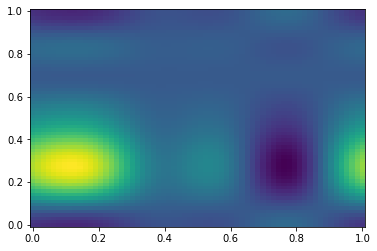

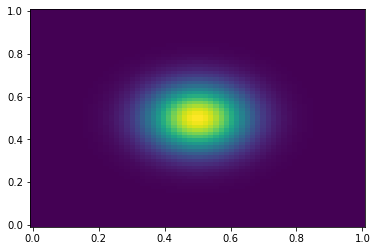

In [20]:
plt.figure()
u = unflatten(u)
plt.pcolormesh(x,y,u,shading='auto')

plt.figure()
plt.pcolormesh(x,y,u_init,shading='auto')

plt.show()